# Plan:

- [x] Start experimenting on the `Turb3_Row1_` sim (simplest one) -- investigate others once GPs and PFNs are tested;
- [x] Collect a dataset of 100k (?) timestamps on the simulation using random sampling (later check if the benchmark authors used a more advanced sampling strategy, since random sampling is naive). Action space has $d=1$ (yaw), so the total feature dim is 3 (one yaw per turbine).
- [x] Fit a simple GP and compare to the RL benchmarks from the paper;
- [ ] Experiment with the sampling strategy (more diverse?);
- [ ] PFN/TabPFN;
- [ ] RL (PPO/DQN etc);

In [1]:
import secrets
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from wfcrl.rewards import StepPercentage
from wfcrl import environments as envs

import torch

sns.set_theme(style="whitegrid")
SEED = 13
N_sim = 10_00 # 100_000

In [2]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
env = envs.make("HornsRev2_Floris", #"Turb3_Row1_Floris", #"Ablaincourt_Floris",#
                max_num_steps=150,
                controls={"yaw": (-5, 5)},
                continuous_control = True, # continuous action space
                log=True)

/users/4/rozan012/weather-vein/wfcrl-env/wfcrl/mdp.py:203: UserWarning: No step size was provided for actuator yaw. Step size will default to 1.
  warn(


In [4]:
def step_policy(i):
    '''Randmoly samples actions'''
    joint_action = {"yaw": np.zeros(env.num_turbines)}
    mask = np.random.random(env.num_turbines) < 0.3 # proba of a turbine to get controled
    joint_action["yaw"][mask] = np.random.uniform(-5, 5, size=mask.sum())
    return joint_action

In [5]:
def obs_to_row(obs, run_id, reward, power, step):
    '''Writes all episode results into a dict'''
    row = {"run_id": run_id, "step": step, "reward": reward[0]}
    for key, val in obs.items():
        val = np.atleast_1d(val)
        if len(val) == 1:
            row[key] = val[0]
        else:
            for i, v in enumerate(val):
                row[f"{key}_{i}"] = v
    for i in range(len(power)):
        row[f"power_{i}"] = power[i]
    return row

In [28]:
env.reset()

OrderedDict([('yaw', array([0., 0., 0.])),
             ('freewind_measurements', array([  5.66263203, 253.25655049])),
             ('wind_speed', array([5.64396869, 5.6019362 , 5.5984242 ])),
             ('wind_direction',
              array([253.55178513, 253.66272609, 253.40412669]))])

In [9]:
sims, max_reward, rows = 0, -np.inf, []
while len(rows) <= N_sim:
    run_id = secrets.token_urlsafe(6)
    observation = env.reset(seed=SEED, options={"wind_speed": 8, "wind_direction": 270}) #  to fix initial conditions
    r, i = 0, 0
    done = False
    while not done:
        joint_action = step_policy(i)
        observation, reward, termination, truncation, info = env.step(joint_action)
        rows.append(obs_to_row(observation, run_id, reward, info["power"], i))  
        r += reward
        i += 1
        done = termination or truncation
    if sims%500==0:
        print(f"Simulation #{sims}: total reward = {r}")
    sims += 1 
    max_reward = max(max_reward, r)
print(f"Maximum total reward: {max_reward}")
sim_summary = pd.DataFrame(rows)
sim_summary

Simulation #0: total reward = [366.95998195]
Maximum total reward: [366.95998195]


,run_id,step,reward,yaw_0,yaw_1,yaw_2,yaw_3,yaw_4,yaw_5,yaw_6,...,power_81,power_82,power_83,power_84,power_85,power_86,power_87,power_88,power_89,power_90
0,CbmyidOk,0,2.458049,0.000000,0.000000,0.000000,-0.614936,0.000000,0.0,0.000000,...,1.517348,1.690871,1.690871,1.197996,1.160968,1.107895,0.976938,0.989387,1.690871,1.690871
1,CbmyidOk,1,2.458934,0.000000,-1.000000,0.000000,-0.614936,-1.000000,0.0,1.000000,...,1.517311,1.690871,1.690871,1.195883,1.162671,1.107472,0.976856,0.989430,1.690871,1.689502
2,CbmyidOk,2,2.459702,-0.252950,0.000000,0.000000,-0.614936,-2.000000,0.0,1.000000,...,1.517188,1.690871,1.690871,1.197580,1.169964,1.107497,0.976895,0.989136,1.690871,1.689502
3,CbmyidOk,3,2.459454,-0.252950,0.000000,0.000000,0.385064,-1.625586,0.0,1.000000,...,1.517137,1.690871,1.689502,1.197734,1.177076,1.108514,0.976718,0.996978,1.690871,1.689502
4,CbmyidOk,4,2.459868,-0.252950,0.000000,0.000000,-0.614936,-1.625586,1.0,1.000000,...,1.517062,1.690871,1.687222,1.204791,1.177049,1.108473,0.976556,1.006179,1.690871,1.689502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,dLLVzH_r,144,2.464419,-1.328351,-0.745942,-1.664549,5.000000,2.198866,4.0,5.000000,...,1.558030,1.686356,1.691302,1.187759,1.155352,1.117922,0.971679,0.980191,1.691101,1.682222
1039,dLLVzH_r,145,2.464191,-1.328351,-0.258835,-1.664549,5.000000,2.198866,4.0,5.000000,...,1.556530,1.686356,1.691302,1.191015,1.155665,1.122308,0.969382,0.978118,1.691291,1.682222
1040,dLLVzH_r,146,2.464141,-2.328351,-0.258835,-2.664548,5.000000,3.198866,4.0,5.000000,...,1.547695,1.688911,1.691302,1.188462,1.155511,1.116623,0.964944,0.978067,1.691291,1.685842
1041,dLLVzH_r,147,2.465044,-2.328351,0.741165,-1.664548,5.000000,3.198866,4.0,5.000000,...,1.546130,1.688911,1.691302,1.181579,1.155815,1.121035,0.967599,0.980144,1.691291,1.685842


In [10]:
sim_summary.to_csv('./data/HornsRev2_Floris.csv', index=None)

# Fitting GP

In [8]:
import torch
from botorch.fit import fit_gpytorch_mll as fit_gpytorch_model
from botorch.models import SingleTaskGP, MultiTaskGP
from botorch.test_functions import Hartmann
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.models.transforms import Normalize, Standardize
from gpytorch.kernels import MaternKernel, RBFKernel, ScaleKernel

/users/4/rozan012/.conda/envs/ppo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
X_base = sim_summary[[f"yaw_{i}" for i in range(env.num_turbines)]+['freewind_measurements_0', 'freewind_measurements_1']].values[:500]
powers = sim_summary[[f'power_{i}' for i in range(env.num_turbines)]].values[:500]

# reshaping such that 1 row is 1 task (turbine)
n = len(X_base)
X_long = np.repeat(X_base, env.num_turbines, axis=0)
task_col = np.tile(list(range(env.num_turbines)), n).reshape(-1, 1)
X_long = np.hstack([X_long, task_col])
Y_long = powers.reshape(-1, 1)

train_X = torch.tensor(X_long, dtype=torch.double)
train_Y = torch.tensor(Y_long, dtype=torch.double)

In [10]:
model = MultiTaskGP(train_X, train_Y, task_feature=-1, input_transform=Normalize(d=6, indices=[0, 1, 2, 3, 4]), 
                    covar_module=ScaleKernel(MaternKernel(nu=0.5, ard_num_dims=5)),
                    outcome_transform=Standardize(m=1))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_model(mll)

/users/4/rozan012/.conda/envs/ppo/lib/python3.11/site-packages/linear_operator/utils/interpolation.py:71: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  summing_matrix = cls(summing_matrix_indices, summing_matrix_values, size)


ExactMarginalLogLikelihood(
  (likelihood): HadamardGaussianLikelihood(
    (noise_covar): MultitaskHomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (model): MultiTaskGP(
    (likelihood): HadamardGaussianLikelihood(
      (noise_covar): MultitaskHomoskedasticNoise(
        (noise_prior): LogNormalPrior()
        (raw_noise_constraint): GreaterThan(1.000E-04)
      )
    )
    (mean_module): MultitaskMean(
      (base_means): ModuleList(
        (0-2): 3 x ConstantMean()
      )
    )
    (covar_module): ProductKernel(
      (kernels): ModuleList(
        (0): ScaleKernel(
          (base_kernel): MaternKernel(
            (raw_lengthscale_constraint): Positive()
          )
          (raw_outputscale_constraint): Positive()
        )
        (1): PositiveIndexKernel(
          (raw_var_constraint): Positive()
          (raw_covar_factor_constraint): GreaterThan(0.000E+00)
        )
      )
    )
    (input_trans

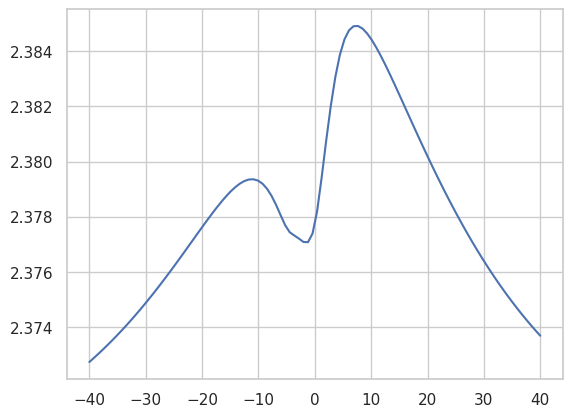

In [12]:
model.eval()
yaws_sweep = np.linspace(-40, 40, 100)
preds = []
for y in yaws_sweep:
    X_in = torch.tensor([[y, 0, 0, 8.0, 270.0]])
    preds.append(model.posterior(X_in).mean.sum().detach().numpy())
plt.plot(yaws_sweep, preds)

In [13]:
model.eval()
observation = env.reset(seed=SEED, options={"wind_speed": 8, "wind_direction": 270})
r, i = 0, 0
done = False

while not done:
    freewind = torch.tensor(observation['freewind_measurements'], dtype=torch.double)
    current_yaw = observation['yaw']
    
    yaws = torch.tensor(current_yaw, dtype=torch.double).requires_grad_(True)
    optimizer = torch.optim.Adam([yaws], lr=1.0) # lr is high since the error surface is smooth and dim=3
    
    for _ in range(100):
        optimizer.zero_grad()
        test_X = torch.stack([
            torch.cat([yaws, freewind, torch.tensor([t], dtype=torch.double)])
            for t in range(3)
        ])
        pred_power = model.posterior(test_X).mean.sum()
        (-pred_power).backward()  # negative for maximization
        optimizer.step()
        yaws.data.clamp_(-5, 5)
    
    joint_action = {'yaw': yaws.detach().numpy() - current_yaw}
    
    observation, reward, termination, truncation, info = env.step(joint_action)
    r += reward
    i += 1
    done = termination or truncation

print(f"Total reward = {r}")

MultiTaskGP(
  (likelihood): HadamardGaussianLikelihood(
    (noise_covar): MultitaskHomoskedasticNoise(
      (noise_prior): LogNormalPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): MultitaskMean(
    (base_means): ModuleList(
      (0-2): 3 x ConstantMean()
    )
  )
  (covar_module): ProductKernel(
    (kernels): ModuleList(
      (0): ScaleKernel(
        (base_kernel): MaternKernel(
          (raw_lengthscale_constraint): Positive()
        )
        (raw_outputscale_constraint): Positive()
      )
      (1): PositiveIndexKernel(
        (raw_var_constraint): Positive()
        (raw_covar_factor_constraint): GreaterThan(0.000E+00)
      )
    )
  )
  (input_transform): Normalize()
  (outcome_transform): Standardize()
)

In [21]:
model.eval()
observation = env.reset(seed=SEED, options={"wind_speed": 8, "wind_direction": 270})
r, i = 0, 0
done = False

while not done:
    '''
    The goal is to optimize the yaw given the trained GP which provides PPD over power given yaws.
    Therefore, having GP approximating the turbine physics we look for the most optimal action without taking any decisions in the 
    simulation itself.
    '''
    freewind = torch.tensor(observation['freewind_measurements'], dtype=torch.double)
    current_yaw = observation['yaw']
    
    yaws = torch.tensor(current_yaw, dtype=torch.double).requires_grad_(True)
    optimizer = torch.optim.Adam([yaws], lr=1.0) # lr is high since the error surface is smooth and dim=3
    
    for _ in range(100):
        optimizer.zero_grad()
        test_X = torch.stack([
            torch.cat([yaws, freewind, torch.tensor([t], dtype=torch.double)])
            for t in range(3)
        ])
        pred_power = model.posterior(test_X).mean.sum()
        (-pred_power).backward()  # negative for maximization
        optimizer.step()
        yaws.data.clamp_(-5, 5)
    
    joint_action = {'yaw': yaws.detach().numpy() - current_yaw}
    
    observation, reward, termination, truncation, info = env.step(joint_action)
    r += reward
    i += 1
    done = termination or truncation

print(f"Total reward = {r}")

Total reward = [351.2924378]


# GPs
**RBF**:
- 15: 317.25
- 150: 325.47
- 500: 325.57

**Matern**:
- 15 (mu=0.5): 313.14
- 150 (mu=0.5): 324.98
- 500 (mu=0.5): 325.29

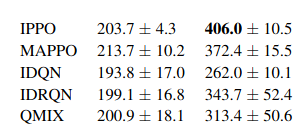